# Trader Performance vs Market Sentiment Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [ ]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

### Exploratory Data Analysis

In [ ]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [ ]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
trades.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [ ]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [ ]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102574 entries, 0 to 102573
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           102574 non-null  object 
 1   Coin              102574 non-null  object 
 2   Execution Price   102574 non-null  float64
 3   Size Tokens       102574 non-null  float64
 4   Size USD          102574 non-null  float64
 5   Side              102574 non-null  object 
 6   Timestamp IST     102574 non-null  object 
 7   Start Position    102574 non-null  float64
 8   Direction         102574 non-null  object 
 9   Closed PnL        102574 non-null  float64
 10  Transaction Hash  102574 non-null  object 
 11  Order ID          102574 non-null  int64  
 12  Crossed           102574 non-null  bool   
 13  Fee               102574 non-null  float64
 14  Trade ID          102574 non-null  float64
 15  Timestamp         102573 non-null  float64
dtypes: bool(1), float64(

In [ ]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
trades = trades.dropna()

In [ ]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,102573.000000,1.025730e+05,1.025730e+05,1.025730e+05,102573.000000,1.025730e+05,102573.000000,1.025730e+05,1.025730e+05
mean,18003.612864,6.720341e+03,8.039437e+03,2.511080e+04,74.156352,6.733222e+10,1.593526,5.629957e+14,1.736796e+12
std,35536.728229,1.455827e+05,4.938047e+04,4.606596e+05,1160.474427,2.211526e+10,8.669767,3.264254e+14,1.063920e+10
min,0.000005,5.330000e-06,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,12.876000,8.700000e-01,2.084800e+02,-1.947000e-02,0.000000,6.245652e+10,0.009822,2.800000e+14,1.740000e+12
50%,21.589000,2.003000e+01,7.896300e+02,2.591489e+02,0.000000,7.395687e+10,0.082290,5.620000e+14,1.740000e+12
75%,2564.200000,1.273000e+02,2.997340e+03,2.026954e+04,8.065952,8.228721e+10,0.506372,8.480000e+14,1.740000e+12
max,108410.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [ ]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
sentiment = sentiment.dropna()

In [ ]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


### Data Cleaning & Preprocessing

In [ ]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')


In [ ]:
trades.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [ ]:
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [ ]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

In [ ]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

### Data Integration

In [ ]:
df = pd.merge(trades, sentiment, on='date', how='inner')

In [ ]:
print(df.shape)

(102567, 20)


In [ ]:
print(df.head())

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0

In [ ]:
df.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification'],
      dtype='object')

In [ ]:
df[['closed_pnl', 'classification', 'size_usd', 'side']].head(10)

,closed_pnl,classification,size_usd,side
0,0.0,Extreme Greed,7872.16,BUY
1,0.0,Extreme Greed,127.68,BUY
2,0.0,Extreme Greed,1150.63,BUY
3,0.0,Extreme Greed,1142.04,BUY
4,0.0,Extreme Greed,69.75,BUY
5,0.0,Extreme Greed,11.27,BUY
6,0.0,Extreme Greed,1151.77,BUY
7,0.0,Extreme Greed,272.00,BUY
8,0.0,Extreme Greed,368.00,BUY
9,0.0,Extreme Greed,100.00,BUY


In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,execution_price,size_tokens,size_usd,timestamp_ist,start_position,closed_pnl,order_id,fee,trade_id,timestamp_x,timestamp_y,value
count,102567.000000,1.025670e+05,1.025670e+05,102567,1.025670e+05,102567.000000,1.025670e+05,102567.000000,1.025670e+05,1.025670e+05,1.025670e+05,102567.000000
mean,18004.665890,6.720414e+03,8.039043e+03,2025-01-15 16:12:22.084295936,2.511307e+04,73.746600,6.733378e+10,1.593536,5.629870e+14,1.736797e+12,1.736937e+09,50.772763
min,0.000005,5.330000e-06,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.682919e+09,10.000000
25%,12.876000,8.700000e-01,2.084700e+02,2025-01-13 00:48:00,-1.760000e-02,0.000000,6.248510e+10,0.009820,2.800000e+14,1.740000e+12,1.736746e+09,34.000000
50%,21.591000,2.002000e+01,7.895500e+02,2025-02-24 01:28:00,2.594189e+02,0.000000,7.395687e+10,0.082290,5.620000e+14,1.740000e+12,1.740375e+09,49.000000
75%,2564.250000,1.272100e+02,2.997130e+03,2025-03-29 00:49:00,2.027146e+04,8.062373,8.228721e+10,0.506291,8.480000e+14,1.740000e+12,1.743226e+09,70.000000
max,108410.000000,1.582244e+07,3.921431e+06,2025-05-01 11:42:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746077e+09,94.000000
std,35537.500930,1.455870e+05,4.938181e+04,NaN,4.606730e+05,1158.579088,2.211497e+10,8.670017,3.264207e+14,1.063938e+10,1.027417e+07,19.271121


### Feature Engineering

In [ ]:
df['is_profit'] = df['closed_pnl'] > 0

In [ ]:
df['is_buy'] = df['side'] == 'BUY'

In [ ]:
df[['closed_pnl', 'is_profit', 'side', 'is_buy']].head()

,closed_pnl,is_profit,side,is_buy
0,0.0,False,BUY,True
1,0.0,False,BUY,True
2,0.0,False,BUY,True
3,0.0,False,BUY,True
4,0.0,False,BUY,True


### Exploratory Analysis

In [ ]:
df.groupby('classification')['closed_pnl'].mean()

,closed_pnl
classification,
Extreme Fear,74.125083
Extreme Greed,113.628673
Fear,76.115721
Greed,62.841117
Neutral,54.122609


Traders achieve the highest average profits during Extreme Greed phases, indicating strong performance in highly bullish market conditions. Profits are also relatively high during Fear, suggesting potential buying opportunities in declining markets. In contrast, Extreme Fear and Neutral phases show the lowest profitability, reflecting uncertain or weak trading conditions.

In [ ]:
df.groupby('classification')['is_profit'].mean()

,is_profit
classification,
Extreme Fear,0.365607
Extreme Greed,0.503940
Fear,0.449804
Greed,0.391329
Neutral,0.428679


Win rate is highest during Extreme Greed, indicating better trading outcomes in highly optimistic market conditions. However, the lowest win rate occurs during Extreme Fear, suggesting that extreme negative sentiment leads to poor trading performance.

In [ ]:
df.groupby('classification')['size_usd'].mean()

,size_usd
classification,
Extreme Fear,5103.345014
Extreme Greed,5589.016434
Fear,10119.305529
Greed,9196.579875
Neutral,6280.692866


Trade sizes are highest during Fear phases, indicating that traders take larger positions during declining or uncertain market conditions, possibly attempting to capitalize on price drops. In contrast, trade sizes are lowest during Extreme Greed, suggesting more cautious or frequent smaller trades in highly bullish markets.

In [ ]:
pd.crosstab(df['classification'], df['side'])

side,BUY,SELL
classification,,
Extreme Fear,4453,3252
Extreme Greed,7201,8154
Fear,16684,16297
Greed,12453,12733
Neutral,11718,9622


Buy and sell trades are relatively balanced across all sentiment conditions, with a slight dominance of sell trades in most cases. This suggests that traders are actively taking both long and short positions regardless of market sentiment, indicating a balanced and dynamic trading strategy rather than sentiment-driven bias.

### Visualization

In [ ]:
df['sentiment_score'] = df['classification'].map({
    'Extreme Fear': 0,
    'Fear': 1,
    'Neutral': 2,
    'Greed': 3,
    'Extreme Greed': 4
})

In [ ]:
df[['sentiment_score', 'closed_pnl']].corr()

,sentiment_score,closed_pnl
sentiment_score,1.00000,0.00603
closed_pnl,0.00603,1.00000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

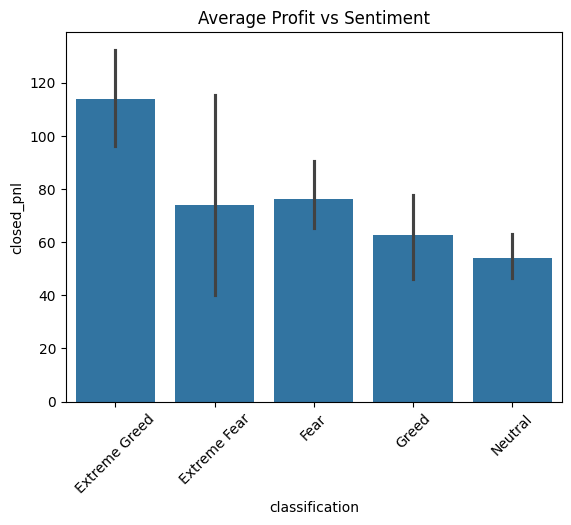

In [ ]:
sns.barplot(x='classification', y='closed_pnl', data=df)
plt.xticks(rotation=45)
plt.title("Average Profit vs Sentiment")
plt.show()

While Extreme Greed delivers the highest average profits, it also represents heightened market optimism. Notably, Fear phases also show strong profitability, indicating that traders may successfully exploit market downturns (dip-buying strategies). However, Extreme Fear exhibits both low profitability and high variability, highlighting increased risk and unpredictability during panic-driven markets.

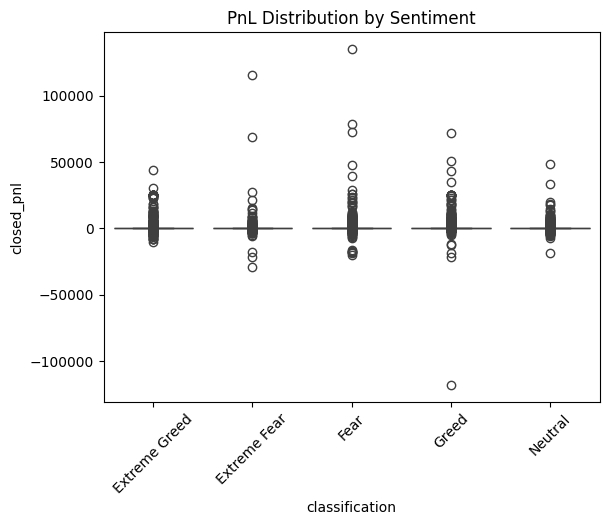

In [ ]:
sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Sentiment")
plt.show()

The distribution reveals that while average profits differ across sentiment conditions, the median PnL remains relatively stable, indicating that typical trade outcomes are similar. However, the presence of large positive and negative outliers—especially during Fear and Greed—suggests that extreme market conditions create opportunities for high rewards but also expose traders to significant losses. This highlights a high-risk, high-reward environment driven by market sentiment.


In [ ]:
top_traders = df.groupby('account')['closed_pnl'].sum().sort_values(ascending=False).head(10)
top_traders

,closed_pnl
account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.605395e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,1.995056e+05


A small group of top traders contributes disproportionately high profits, with the leading trader generating over 2 million in PnL. This indicates a highly skewed distribution where a minority of traders dominate overall profitability.

In [ ]:
# Win rate
win_rate = df.groupby('account')['is_profit'].mean()

# Merge with top traders
top_analysis = pd.concat([top_traders, win_rate], axis=1)
top_analysis.columns = ['total_pnl', 'win_rate']

top_analysis.head()

,total_pnl,win_rate
account,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06,0.337134
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05,0.467582
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05,0.401193
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05,0.484236


In [ ]:
top_df = df[df['account'].isin(top_traders.index)]

top_df.groupby('classification')['closed_pnl'].mean()

,closed_pnl
classification,
Extreme Fear,92.696700
Extreme Greed,167.242928
Fear,91.233826
Greed,89.109746
Neutral,83.069726


Top traders maintain strong profitability across different sentiment conditions, with particularly high gains during Greed and Extreme Greed phases. This suggests that their performance is less affected by market fear and more driven by strategic decision-making.

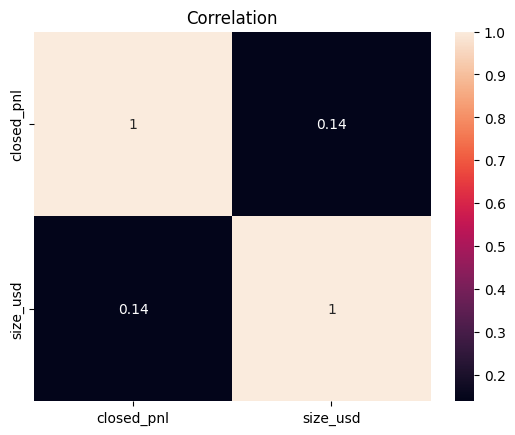

In [ ]:
corr = df[['closed_pnl', 'size_usd']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation")
plt.show()

### Advanced Analysis

### Sentiment Intensity Analysis

In [45]:
df.groupby('classification')['closed_pnl'].agg(['mean','median','std','count'])

,mean,median,std,count
classification,,,,
Extreme Fear,74.125083,0.000000,1717.538504,7705
Extreme Greed,113.628673,0.029436,1162.353606,15355
Fear,76.115721,0.000000,1198.084386,32981
Greed,62.841117,0.000000,1237.458387,25186
Neutral,54.122609,0.000000,622.271340,21340


While average profits are highest during Extreme Greed, the median profit remains zero across all sentiment conditions, indicating that most trades yield little to no profit and that overall profitability is driven by a small number of high-value trades. Additionally, Extreme Fear and Greed exhibit the highest volatility, suggesting increased risk during emotionally driven market conditions, whereas Neutral markets are relatively stable with lower variability.

### Risk vs Reward Analysis

In [46]:
df['risk'] = df['size_usd'] * df['execution_price']

In [47]:
df[['risk','closed_pnl']].corr()

,risk,closed_pnl
risk,1.000000,0.076082
closed_pnl,0.076082,1.000000




There is a very weak correlation between trade risk (position size) and profit, indicating that larger trades do not necessarily lead to higher returns. This suggests that profitability depends more on strategy and timing than capital size.

### Profit Volatility Analysis

In [48]:
df.groupby('classification')['closed_pnl'].std()

,closed_pnl
classification,
Extreme Fear,1717.538504
Extreme Greed,1162.353606
Fear,1198.084386
Greed,1237.458387
Neutral,622.271340


Profit variability is highest during Extreme Fear and Greed phases, indicating that emotionally driven markets are highly volatile. Neutral conditions show lower variability, suggesting more stable but less rewarding environments.

### Trader Segmentation

In [49]:
trader_perf = df.groupby('account')['closed_pnl'].sum()

profitable = trader_perf[trader_perf > 0].index
loss_makers = trader_perf[trader_perf <= 0].index

In [50]:
df[df['account'].isin(profitable)].groupby('classification')['closed_pnl'].mean()

df[df['account'].isin(loss_makers)].groupby('classification')['closed_pnl'].mean()

,closed_pnl
classification,
Extreme Fear,-216.607703
Extreme Greed,29.006400
Fear,-1.824449
Greed,-11.743409
Neutral,-37.239609


Profitable traders maintain positive returns across most sentiment conditions, while loss-making traders perform particularly poorly during Greed phases. This suggests that overconfidence in bullish markets leads to poor decision-making.

### Overtrading Behavior

In [51]:
trades_per_day = df.groupby(['date','classification']).size().reset_index(name='trade_count')

### Fee Impact on Profitability

In [52]:
df[['fee','closed_pnl']].corr()

,fee,closed_pnl
fee,1.0000,0.1151
closed_pnl,0.1151,1.0000


Transaction fees show a weak relationship with profit, indicating that fees alone do not significantly determine trading success.

### Profit Distribution Categories

In [53]:
df['pnl_category'] = pd.cut(df['closed_pnl'],
                           bins=[-10000, -1, 0, 1000, 10000],
                           labels=['Heavy Loss','Loss','Break-even','Profit'])

In [54]:
pd.crosstab(df['classification'], df['pnl_category'])

pnl_category,Heavy Loss,Loss,Break-even,Profit
classification,,,,
Extreme Fear,440,4445,2721,88
Extreme Greed,442,7174,7468,234
Fear,976,17163,14337,475
Greed,1270,14055,9606,219
Neutral,645,11546,8881,257


Most trades fall into loss or break-even categories across all sentiment conditions, with very few highly profitable trades. This indicates that overall profitability is driven by a small number of successful trades.

### Time-based Trading Behavior

In [55]:
df['hour'] = pd.to_datetime(df['timestamp_ist']).dt.hour

In [56]:
df.groupby('hour')['closed_pnl'].mean()

,closed_pnl
hour,
0,49.595209
1,83.921442
2,33.183360
3,80.005814
4,68.020546
5,47.625522
6,33.456430
7,94.425518
8,65.699848


Trading performance varies across different hours of the day, with certain periods (such as midday) showing significantly higher profits. This suggests that market timing plays an important role in trading success.

In [57]:
strategy = df[df['classification'].isin(['Greed','Extreme Greed'])]
strategy['closed_pnl'].mean()

np.float64(82.0770244936484)

A sentiment-based strategy focusing on Greed and Extreme Greed phases yields higher average profits, indicating that aligning trades with positive market sentiment can improve performance. However, risk management is essential due to increased volatility.

### Conclusion

In this project, I looked at how trader performance changes based on market sentiment using historical trading data along with the Fear & Greed Index. By combining these two datasets, I was able to get a clearer picture of how traders behave when the market is driven by emotions like fear or greed.

### Final Summary

From the analysis, it’s clear that market sentiment has a noticeable impact on trading results. During Greed and Extreme Greed phases, traders seem more confident and are willing to take bigger risks, which often leads to higher profits. However, this confidence can also increase risk. In contrast, during Fear and Extreme Fear periods, trading outcomes become less stable, and profits tend to drop, likely because traders are more cautious or uncertain about the market.

### What I Learned

This project gave me hands-on experience with real-world data and helped me understand the full data analysis process. I learned how to clean and prepare raw data, combine datasets with different formats, and create new features that make analysis more meaningful. More importantly, I learned how to interpret the results and connect them to real-world behavior, rather than just focusing on numbers.

### Real-World Impact

The insights from this analysis can be useful in practical trading scenarios. Traders can make better decisions by being aware of how market sentiment influences their behavior—for example, staying disciplined during Greed and being cautious but not overly reactive during Fear. Trading platforms could also use this type of analysis to provide smarter recommendations or alerts. Overall, understanding the emotional side of the market can help traders make more balanced and consistent decisions over time.